Fetching data from Yahoo Finance...
  Loaded 1567 trading days from 2020-01-02 to 2026-03-27

Running backtest on 1558 days...

═════════════════════════════════════════════
  BACKTEST RESULTS
═════════════════════════════════════════════
  Total Trades                 10
  Winning Trades               7
  Losing Trades                3
  Win Rate (%)                 70.0
  Total Gross P&L ($)          11186.35
  Total Commission ($)         1042.11
  Total Net P&L ($)            10144.24
  Avg Net P&L/Trade ($)        1014.42
  Best Trade ($)               2564.08
  Worst Trade ($)              -2293.72
  Avg Duration (days)          224.9
  Sharpe (annualised)          0.7
  Max Drawdown ($)             -2458.68
═════════════════════════════════════════════

Chart saved → faang_arbitrage_results.png


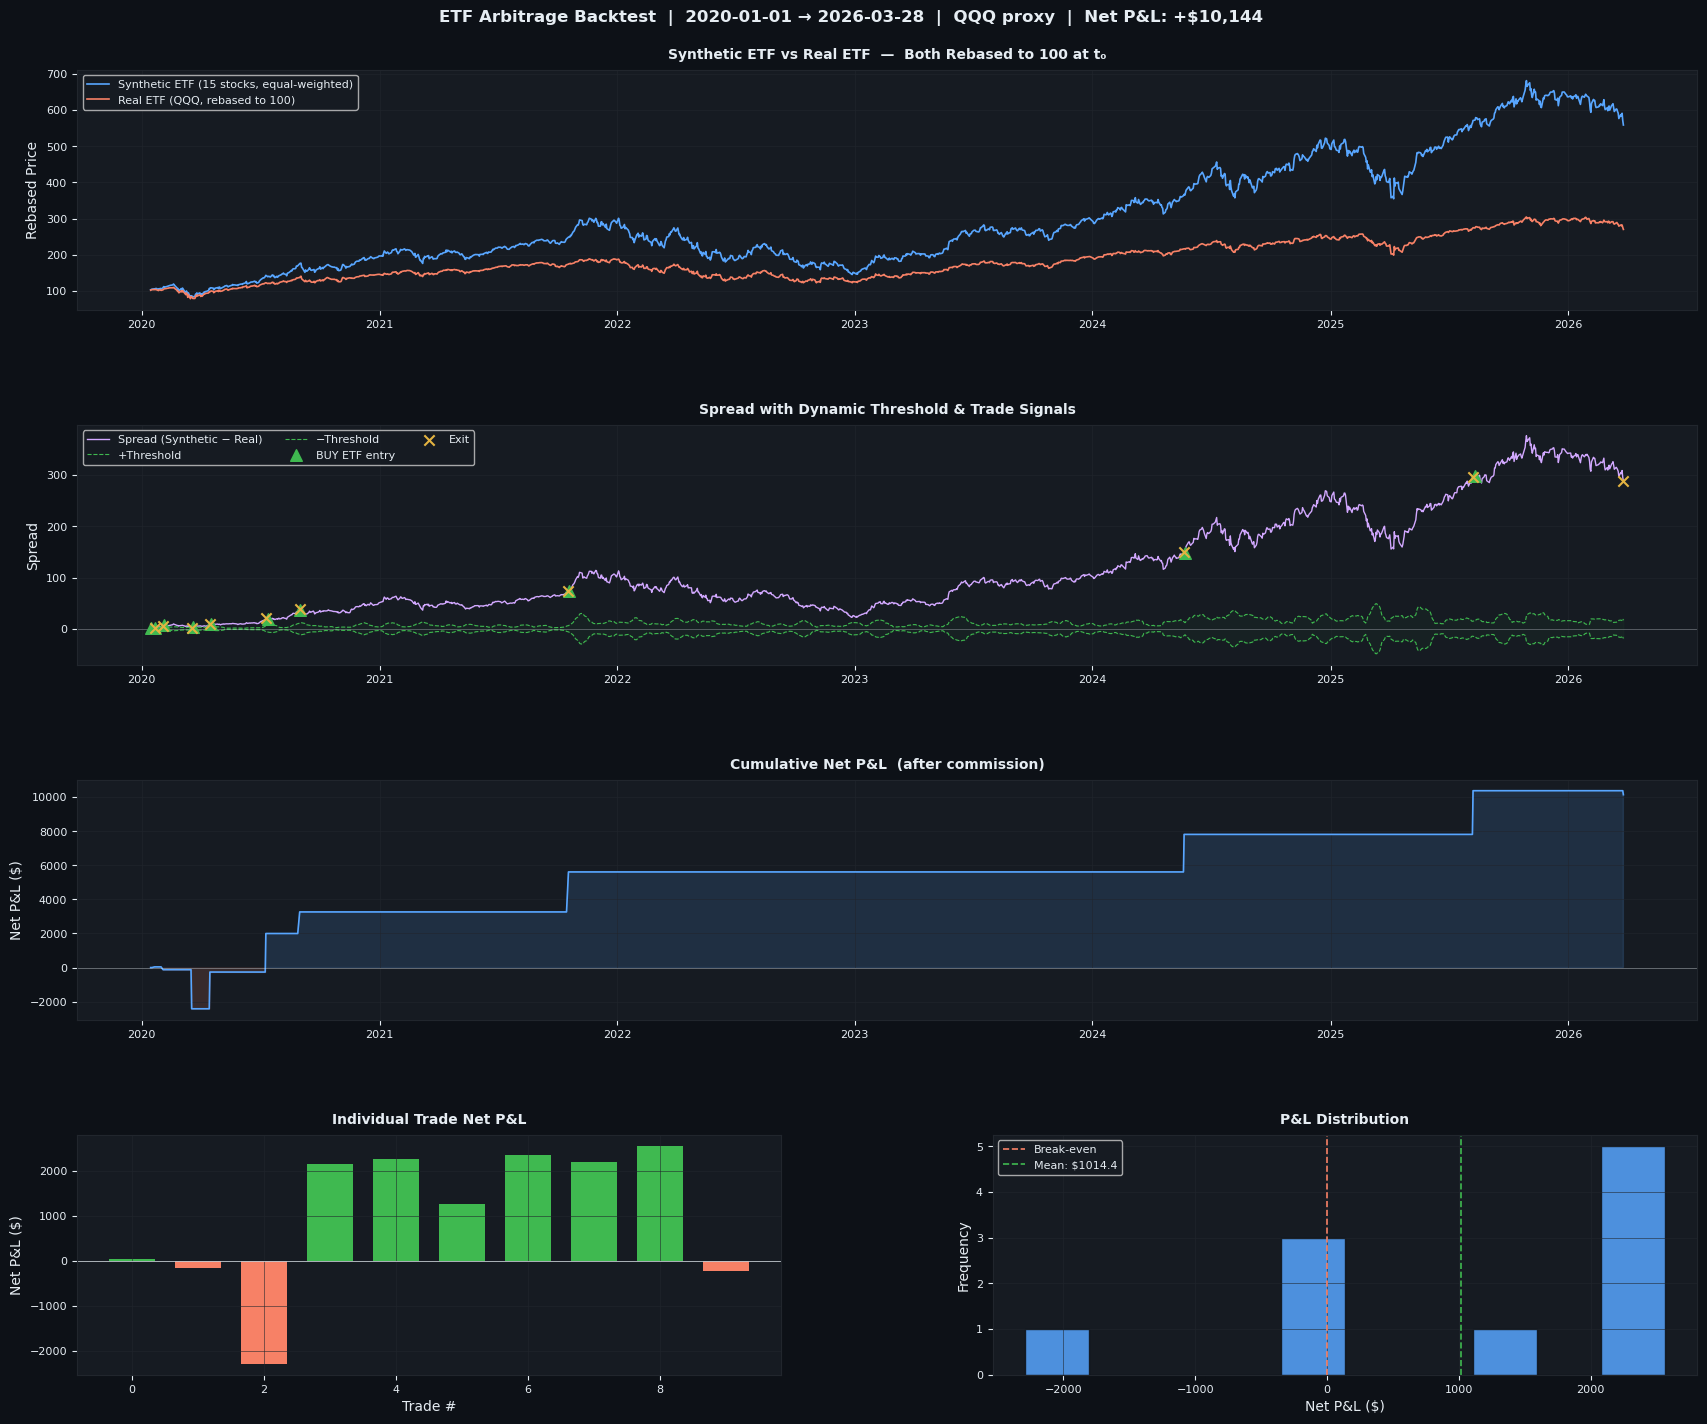

Fetching data from Yahoo Finance...
  Loaded 1567 trading days from 2020-01-02 to 2026-03-27

─────────────────────────────────────────────
  TRAIN SET  (2020-01-15 → 2024-05-14)
─────────────────────────────────────────────

═════════════════════════════════════════════
  BACKTEST RESULTS
═════════════════════════════════════════════
  Total Trades                 8
  Winning Trades               6
  Losing Trades                2
  Win Rate (%)                 75.0
  Total Gross P&L ($)          8384.69
  Total Commission ($)         831.91
  Total Net P&L ($)            7552.78
  Avg Net P&L/Trade ($)        944.1
  Best Trade ($)               2347.03
  Worst Trade ($)              -2293.72
  Avg Duration (days)          196.4
  Sharpe (annualised)          0.71
  Max Drawdown ($)             -2458.68
═════════════════════════════════════════════

─────────────────────────────────────────────
  TEST SET   (2024-05-15 → 2026-03-27)
─────────────────────────────────────────────

════

In [8]:
"""
FAANG ETF Arbitrage Backtesting System

Strategy:
- Construct a "Synthetic ETF" by rebasing top QQQ stocks to 100 at t0 and averaging
- Compare against QQQ (real ETF proxy), also rebased to 100
- Trade when spread diverges beyond a dynamic threshold (rolling std * multiplier)
- Exit when spread reverts toward zero, or stop-loss triggered

Requirements:
    pip install yfinance pandas numpy matplotlib
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')



# 1. CONFIGURATION of essential parameters


CONFIG = {
    "tickers": [
        "AAPL", "MSFT", "NVDA", "AMZN", "META",
        "GOOGL", "GOOG", "TSLA", "AVGO", "COST",
        "NFLX", "AMD", "ADBE", "QCOM", "INTC"
    ],
    "etf_proxy":        "QQQ",
    "start_date":       "2020-01-01",
    "end_date":         "2026-03-28",
    "commission_pct":   0.005,   # 0.1% is a realistic retail commission, but increased the commission percentage to ensure the strategy is robust
    "threshold_window": 20,      # rolling window for dynamic threshold (days)
    "threshold_mult":   2,     # only trade on genuine outliers (2 * rolling std)
    "dollar_notional":  10000,    # fixed $ per trade — consistent position sizing
    "min_hold_days":    3,       # never exit within 3 days — prevents churn
}


# 2. DATA FETCHING


def fetch_data(tickers, etf, start, end):
    """Download adjusted close prices for all tickers and the ETF."""
    print("Fetching data from Yahoo Finance...")
    all_tickers = tickers + [etf]
    raw = yf.download(all_tickers, start=start, end=end, auto_adjust=True, progress=False)["Close"]
    raw.dropna(inplace=True)
    print(f"  Loaded {len(raw)} trading days from {raw.index[0].date()} to {raw.index[-1].date()}")
    return raw



# 3. SYNTHETIC ETF CONSTRUCTION


def build_synthetic_etf(prices_df, tickers):
    """
    Rebase each stock to 100 at t0, then take equal-weighted average.
    Mirrors exactly how the Capula assessment defines the synthetic ETF.
    """
    t0 = prices_df[tickers].iloc[0]
    rebased = (prices_df[tickers] / t0) * 100
    synthetic = rebased.mean(axis=1)
    synthetic.name = "Synthetic_ETF"
    return synthetic, rebased


def build_real_etf(prices_df, etf_col):
    """Rebase the real ETF to 100 at t0 so it is directly comparable to synthetic."""
    t0 = prices_df[etf_col].iloc[0]
    real = (prices_df[etf_col] / t0) * 100
    real.name = "Real_ETF"
    return real



# 4. SPREAD & THRESHOLD


def compute_spread(synthetic, real_etf):
    """
    Spread = Synthetic ETF - Real ETF.
    Positive: synthetic overpriced vs real → BUY real ETF, SELL stocks.
    Negative: real ETF overpriced vs synthetic → SELL real ETF, BUY stocks.
    """
    spread = synthetic - real_etf
    spread.name = "Spread"
    return spread


def compute_dynamic_threshold(spread, window, multiplier):
    """
    Rolling std threshold — adapts to the current volatility regime.
    Higher multiplier = fewer but higher-conviction trades.
    """
    rolling_std = spread.rolling(window=window, min_periods=window // 2).std()
    threshold = rolling_std * multiplier
    threshold.name = "Threshold"
    return threshold



# 5. POSITION CLASS


class Position:
    """Tracks a single open/closed position."""
    def __init__(self, direction, entry_price, entry_date, volume, commission):
        self.direction       = direction   # 'LONG_ETF' or 'SHORT_ETF'
        self.entry_price     = entry_price
        self.entry_date      = entry_date
        self.volume          = volume
        self.commission_paid = commission
        self.exit_price      = None
        self.exit_date       = None
        self.pnl             = None
        self.pnl_net         = None



# 6. BACKTESTING ENGINE


class BacktestEngine:
    """
    Simulates the ETF arbitrage strategy day by day.

    Entry rules:
      Spread > +threshold  →  BUY real ETF (LONG_ETF), sell stocks
      Spread < -threshold  →  SELL real ETF (SHORT_ETF), buy stocks

    Exit rules:
      Profit-take: spread reverts to within 30% of threshold
      Stop-loss:   spread moves 2x further against the position
      Min hold:    never exit within min_hold_days of entry
    """

    def __init__(self, commission_pct, dollar_notional):
        self.commission_pct   = commission_pct
        self.dollar_notional  = dollar_notional
        self.trades           = []
        self.current_position = None
        self.equity_curve     = []
        self.spread_at_entry  = None

    def _commission(self, price, vol):
        return price * vol * self.commission_pct

    def _open_trade(self, direction, etf_price, date):
        """Open a new position sized by dollar notional."""
        volume     = max(1, int(self.dollar_notional / etf_price))
        commission = self._commission(etf_price, volume)
        self.current_position = Position(
            direction=direction,
            entry_price=etf_price,
            entry_date=date,
            volume=volume,
            commission=commission
        )

    def _close_trade(self, etf_price, date):
        """Close current position, calculate P&L net of both commissions."""
        pos = self.current_position
        pos.exit_price = etf_price
        pos.exit_date  = date

        exit_commission   = self._commission(etf_price, pos.volume)
        pos.commission_paid += exit_commission

        if pos.direction == 'LONG_ETF':
            pos.pnl = (pos.exit_price - pos.entry_price) * pos.volume
        else:
            pos.pnl = (pos.entry_price - pos.exit_price) * pos.volume

        pos.pnl_net = pos.pnl - pos.commission_paid
        self.trades.append(pos)
        self.current_position = None
        self.spread_at_entry  = None
        return pos.pnl_net

    def run(self, df, min_hold_days=3):
        """
        Iterate day by day over the prepared dataframe.
        df must contain: Spread, Threshold, Real_ETF_Raw
        """
        cumulative_pnl = 0.0

        for date, row in df.iterrows():
            spread    = row["Spread"]
            threshold = row["Threshold"]
            etf_price = row["Real_ETF_Raw"]

            # Skip rows in warm-up period where threshold not yet computed
            if pd.isna(threshold) or pd.isna(spread):
                self.equity_curve.append((date, cumulative_pnl))
                continue

            pos = self.current_position

            # ── Entry logic ───────────────────────────────────────────────
            if pos is None:
                if spread > threshold:
                    # Synthetic overpriced → BUY cheap real ETF
                    self._open_trade('LONG_ETF', etf_price, date)
                    self.spread_at_entry = spread

                elif spread < -threshold:
                    # Real ETF overpriced → SELL expensive real ETF
                    self._open_trade('SHORT_ETF', etf_price, date)
                    self.spread_at_entry = spread

            # ── Exit logic ────────────────────────────────────────────────
            else:
                # Enforce minimum holding period to prevent churn
                days_held = (date - pos.entry_date).days
                if days_held < min_hold_days:
                    self.equity_curve.append((date, cumulative_pnl))
                    continue

                should_exit = False

                # Profit-take: spread has reverted back toward zero
                if pos.direction == 'LONG_ETF' and spread < threshold * 0.3:
                    should_exit = True
                elif pos.direction == 'SHORT_ETF' and spread > -threshold * 0.3:
                    should_exit = True

                # Stop-loss: spread moved further against the position
                elif pos.direction == 'LONG_ETF' and spread > self.spread_at_entry * 2.0:
                    should_exit = True
                elif pos.direction == 'SHORT_ETF' and spread < -(abs(self.spread_at_entry) * 2.0):
                    should_exit = True

                if should_exit:
                    pnl = self._close_trade(etf_price, date)
                    cumulative_pnl += pnl

            self.equity_curve.append((date, cumulative_pnl))

        # Force-close any position still open at end of data
        if self.current_position is not None:
            last_row = df.iloc[-1]
            pnl = self._close_trade(last_row["Real_ETF_Raw"], df.index[-1])
            cumulative_pnl += pnl
            self.equity_curve[-1] = (df.index[-1], cumulative_pnl)

    #Performance metrics

    def summary(self):
        if not self.trades:
            print("No trades executed.")
            return {}

        pnls        = [t.pnl_net for t in self.trades]
        gross       = [t.pnl for t in self.trades]
        commissions = [t.commission_paid for t in self.trades]
        durations   = [(t.exit_date - t.entry_date).days for t in self.trades]
        winners     = [p for p in pnls if p > 0]
        losers      = [p for p in pnls if p <= 0]

        stats = {
            "Total Trades":          len(self.trades),
            "Winning Trades":        len(winners),
            "Losing Trades":         len(losers),
            "Win Rate (%)":          round(len(winners) / len(self.trades) * 100, 1),
            "Total Gross P&L ($)":   round(sum(gross), 2),
            "Total Commission ($)":  round(sum(commissions), 2),
            "Total Net P&L ($)":     round(sum(pnls), 2),
            "Avg Net P&L/Trade ($)": round(np.mean(pnls), 2),
            "Best Trade ($)":        round(max(pnls), 2),
            "Worst Trade ($)":       round(min(pnls), 2),
            "Avg Duration (days)":   round(np.mean(durations), 1),
            "Sharpe (annualised)":   round(self._sharpe(), 2),
            "Max Drawdown ($)":      round(self._max_drawdown(), 2),
        }

        print("\n" + "═" * 45)
        print("  BACKTEST RESULTS")
        print("═" * 45)
        for k, v in stats.items():
            print(f"  {k:<28} {v}")
        print("═" * 45)
        return stats

    def _sharpe(self):
        eq = pd.Series([e[1] for e in self.equity_curve])
        daily_ret = eq.diff().dropna()
        if daily_ret.std() == 0:
            return 0.0
        return (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)

    def _max_drawdown(self):
        eq = pd.Series([e[1] for e in self.equity_curve])
        peak = eq.cummax()
        return (eq - peak).min()



# 7. VISUALISATION


def plot_results(df, engine, config):
    """
    4-panel performance dashboard:
      Panel 1 (full width): Synthetic vs Real ETF rebased to 100
      Panel 2 (full width): Spread with threshold bands and trade markers
      Panel 3 (full width): Equity curve (cumulative net P&L)
      Panel 4a:             Individual trade P&L bar chart
      Panel 4b:             P&L distribution histogram
    """
    equity_dates  = [e[0] for e in engine.equity_curve]
    equity_vals   = [e[1] for e in engine.equity_curve]
    equity_series = pd.Series(equity_vals, index=equity_dates)

    # Build trade marker lists — only include dates present in df index
    long_entries  = [(t.entry_date, df.loc[t.entry_date, "Spread"])
                     for t in engine.trades
                     if t.direction == 'LONG_ETF' and t.entry_date in df.index]
    short_entries = [(t.entry_date, df.loc[t.entry_date, "Spread"])
                     for t in engine.trades
                     if t.direction == 'SHORT_ETF' and t.entry_date in df.index]
    exits         = [(t.exit_date, df.loc[t.exit_date, "Spread"])
                     for t in engine.trades
                     if t.exit_date in df.index]

    #Colours
    bg_dark    = '#0d1117'
    bg_panel   = '#161b22'
    grid_col   = '#21262d'
    txt_col    = '#e6edf3'
    synth_col  = '#58a6ff'
    real_col   = '#f78166'
    spread_col = '#d2a8ff'
    thresh_col = '#3fb950'
    eq_col     = '#58a6ff'
    buy_col    = '#3fb950'
    sell_col   = '#f78166'
    exit_col   = '#e3b341'

    fig = plt.figure(figsize=(18, 15), facecolor=bg_dark)
    gs  = gridspec.GridSpec(4, 2, figure=fig,
                            hspace=0.48, wspace=0.3,
                            left=0.07, right=0.97, top=0.93, bottom=0.06)

    def style_ax(ax, title):
        ax.set_facecolor(bg_panel)
        ax.tick_params(colors=txt_col, labelsize=8)
        ax.set_title(title, color=txt_col, fontsize=10, fontweight='bold', pad=8)
        for spine in ax.spines.values():
            spine.set_color(grid_col)
        ax.grid(True, color=grid_col, linewidth=0.5, alpha=0.8)
        ax.yaxis.label.set_color(txt_col)
        ax.xaxis.label.set_color(txt_col)

    #ETF comparison
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df.index, df["Synthetic_ETF"], color=synth_col, lw=1.2,
             label=f"Synthetic ETF ({len(config['tickers'])} stocks, equal-weighted)")
    ax1.plot(df.index, df["Real_ETF"],      color=real_col,  lw=1.2,
             label=f"Real ETF ({config['etf_proxy']}, rebased to 100)")
    style_ax(ax1, "Synthetic ETF vs Real ETF  —  Both Rebased to 100 at t\u2080")
    ax1.legend(facecolor=bg_panel, labelcolor=txt_col, fontsize=8, loc='upper left')
    ax1.set_ylabel("Rebased Price")

    # Spread + threshold + trade signals
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(df.index,  df["Spread"],    color=spread_col, lw=1.0,
             label="Spread (Synthetic \u2212 Real)")
    ax2.plot(df.index,  df["Threshold"], color=thresh_col, lw=0.8, ls='--',
             label="+Threshold")
    ax2.plot(df.index, -df["Threshold"], color=thresh_col, lw=0.8, ls='--',
             label="\u2212Threshold")
    ax2.fill_between(df.index,  df["Threshold"], -df["Threshold"],
                     color=thresh_col, alpha=0.04)
    ax2.axhline(0, color=txt_col, lw=0.5, alpha=0.4)

    if long_entries:
        ax2.scatter([e[0] for e in long_entries], [e[1] for e in long_entries],
                    color=buy_col,  marker='^', s=70, zorder=5, label='BUY ETF entry')
    if short_entries:
        ax2.scatter([e[0] for e in short_entries], [e[1] for e in short_entries],
                    color=sell_col, marker='v', s=70, zorder=5, label='SELL ETF entry')
    if exits:
        ax2.scatter([e[0] for e in exits], [e[1] for e in exits],
                    color=exit_col, marker='x', s=55, zorder=5, label='Exit')

    style_ax(ax2, "Spread with Dynamic Threshold & Trade Signals")
    ax2.legend(facecolor=bg_panel, labelcolor=txt_col, fontsize=8,
               ncol=3, loc='upper left')
    ax2.set_ylabel("Spread")

    #Equity curve
    ax3 = fig.add_subplot(gs[2, :])
    ev = equity_series.values
    ax3.plot(equity_series.index, ev, color=eq_col, lw=1.2)
    ax3.fill_between(equity_series.index, 0, ev,
                     where=(ev >= 0), color=eq_col,   alpha=0.15)
    ax3.fill_between(equity_series.index, 0, ev,
                     where=(ev <  0), color=real_col, alpha=0.15)
    ax3.axhline(0, color=txt_col, lw=0.5, alpha=0.5)
    style_ax(ax3, "Cumulative Net P&L  (after commission)")
    ax3.set_ylabel("Net P&L ($)")

    # Per-trade P&L bar chart 
    ax4 = fig.add_subplot(gs[3, 0])
    pnls       = [t.pnl_net for t in engine.trades]
    bar_colors = [buy_col if p > 0 else sell_col for p in pnls]
    ax4.bar(range(len(pnls)), pnls, color=bar_colors, width=0.7)
    ax4.axhline(0, color=txt_col, lw=0.5)
    style_ax(ax4, "Individual Trade Net P&L")
    ax4.set_xlabel("Trade #")
    ax4.set_ylabel("Net P&L ($)")

    #P&L distribution
    ax5 = fig.add_subplot(gs[3, 1])
    ax5.hist(pnls, bins=min(20, len(pnls)), color=synth_col,
             edgecolor=bg_dark, alpha=0.85)
    ax5.axvline(0,             color=real_col,  lw=1.2, ls='--', label='Break-even')
    ax5.axvline(np.mean(pnls), color=thresh_col, lw=1.2, ls='--',
                label=f'Mean: ${np.mean(pnls):.1f}')
    style_ax(ax5, "P&L Distribution")
    ax5.set_xlabel("Net P&L ($)")
    ax5.set_ylabel("Frequency")
    ax5.legend(facecolor=bg_panel, labelcolor=txt_col, fontsize=8)

    #Overall Title
    total_net = sum(pnls)
    sign      = "+" if total_net >= 0 else ""
    fig.suptitle(
        f"ETF Arbitrage Backtest  |  {config['start_date']} \u2192 {config['end_date']}  "
        f"|  {config['etf_proxy']} proxy  |  Net P&L: {sign}${total_net:,.0f}",
        color=txt_col, fontsize=12, fontweight='bold', y=0.97
    )

    plt.savefig("faang_arbitrage_results.png", dpi=150,
                bbox_inches='tight', facecolor=bg_dark)
    print("\nChart saved \u2192 faang_arbitrage_results.png")
    plt.show()



# 8. TRAIN / TEST SPLIT EVALUATION


def run_train_test(config=CONFIG):
    """
    Splits data into train (first 70%) and test (last 30%) to check for overfitting.
    Parameters should only be tuned on train; test result reveals true robustness.
    """
    prices = fetch_data(
        config["tickers"], config["etf_proxy"],
        config["start_date"], config["end_date"]
    )

    synthetic, rebased = build_synthetic_etf(prices, config["tickers"])
    real_etf_rebased   = build_real_etf(prices, config["etf_proxy"])
    spread             = compute_spread(synthetic, real_etf_rebased)
    threshold          = compute_dynamic_threshold(
        spread, config["threshold_window"], config["threshold_mult"]
    )

    df = pd.DataFrame({
        "Synthetic_ETF": synthetic,
        "Real_ETF":      real_etf_rebased,
        "Real_ETF_Raw":  prices[config["etf_proxy"]],
        "Spread":        spread,
        "Threshold":     threshold,
    })
    df.dropna(inplace=True)

    split_idx  = int(len(df) * 0.7)
    train_df   = df.iloc[:split_idx]
    test_df    = df.iloc[split_idx:]

    print(f"\n{'─'*45}")
    print(f"  TRAIN SET  ({train_df.index[0].date()} \u2192 {train_df.index[-1].date()})")
    print(f"{'─'*45}")
    engine_train = BacktestEngine(config["commission_pct"], config["dollar_notional"])
    engine_train.run(train_df, min_hold_days=config.get("min_hold_days", 3))
    engine_train.summary()

    print(f"\n{'─'*45}")
    print(f"  TEST SET   ({test_df.index[0].date()} \u2192 {test_df.index[-1].date()})")
    print(f"{'─'*45}")
    engine_test = BacktestEngine(config["commission_pct"], config["dollar_notional"])
    engine_test.run(test_df, min_hold_days=config.get("min_hold_days", 3))
    engine_test.summary()

    print("\nIf test results are similar to train, the strategy is robust.")
    print("If test results collapse, the parameters are overfit to train data.")



# 9. MAIN PIPELINE


def run_backtest(config=CONFIG):
    # 1. Fetch prices
    prices = fetch_data(
        config["tickers"], config["etf_proxy"],
        config["start_date"], config["end_date"]
    )

    # 2. Build ETFs
    synthetic, rebased = build_synthetic_etf(prices, config["tickers"])
    real_etf_rebased   = build_real_etf(prices, config["etf_proxy"])

    # 3. Compute spread and dynamic threshold
    spread    = compute_spread(synthetic, real_etf_rebased)
    threshold = compute_dynamic_threshold(
        spread, config["threshold_window"], config["threshold_mult"]
    )

    # 4. Assemble master dataframe
    df = pd.DataFrame({
        "Synthetic_ETF": synthetic,
        "Real_ETF":      real_etf_rebased,
        "Real_ETF_Raw":  prices[config["etf_proxy"]],
        "Spread":        spread,
        "Threshold":     threshold,
    })
    df.dropna(inplace=True)

    for t in config["tickers"]:
        df[f"{t}_rebased"] = rebased[t]

    # 5. Run backtest
    print(f"\nRunning backtest on {len(df)} days...")
    engine = BacktestEngine(
        commission_pct=config["commission_pct"],
        dollar_notional=config["dollar_notional"]
    )
    engine.run(df, min_hold_days=config.get("min_hold_days", 3))

    # 6. Print results
    stats = engine.summary()

    # 7. Plot dashboard
    plot_results(df, engine, config)

    return df, engine, stats



# ENTRY POINT


if __name__ == "__main__":
    # Full backtest + visualisation
    df, engine, stats = run_backtest()

    # train/test overfitting check
    run_train_test()